In [33]:
import pandas as pd
import numpy as  np

In [34]:
import os
print(os.getcwd())




d:\MiniProject3_Medical Appointment(ML)\Notebook


In [35]:


df = pd.read_csv("../Data/Medical_appointment_data.csv")

print(df.head())

        specialty  appointment_time gender no_show    disability  \
0   psychotherapy                17      F     yes  intellectual   
1             NaN                 7      M      no  intellectual   
2  speech therapy                16      M      no  intellectual   
3  speech therapy                14      M     yes  intellectual   
4   physiotherapy                 8      M      no         motor   

              place appointment_shift   age  under_12_years_old  \
0  Lake Marvinville         afternoon   9.0                   1   
1           ITAPEMA           morning  11.0                   1   
2            ITAJAÍ         afternoon   8.0                   1   
3         Sarahside         afternoon   9.0                   1   
4            ITAJAÍ           morning   NaN                   0   

   over_60_years_old  ...  storm_day_before  rain_intensity  heat_intensity  \
0                  0  ...                 1         no_rain            warm   
1                  0  ...     

In [36]:
df.shape

(109593, 26)

In [37]:
df.duplicated().sum()

np.int64(36)

In [38]:
df.drop_duplicates(inplace=True)

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.shape


(109557, 26)

In [41]:
df.isnull().sum()

specialty                      20100
appointment_time                   0
gender                             0
no_show                            0
disability                     16571
place                          11509
appointment_shift                  0
age                            22929
under_12_years_old                 0
over_60_years_old                  0
patient_needs_companion            0
average_temp_day                2191
average_rain_day                2225
max_temp_day                    2207
max_rain_day                    2243
rainy_day_before                   0
storm_day_before                   0
rain_intensity                     0
heat_intensity                     0
appointment_date_continuous        0
Hipertension                       0
Diabetes                           0
Alcoholism                         0
Handcap                            0
Scholarship                        0
SMS_received                       0
dtype: int64

In [42]:
missing = (df.isnull().sum() / len(df)) * 100

missing.sort_values(ascending=False)

age                            20.928832
specialty                      18.346614
disability                     15.125460
place                          10.505034
max_rain_day                    2.047336
average_rain_day                2.030906
max_temp_day                    2.014476
average_temp_day                1.999872
appointment_time                0.000000
no_show                         0.000000
over_60_years_old               0.000000
under_12_years_old              0.000000
appointment_shift               0.000000
gender                          0.000000
patient_needs_companion         0.000000
rainy_day_before                0.000000
storm_day_before                0.000000
rain_intensity                  0.000000
heat_intensity                  0.000000
appointment_date_continuous     0.000000
Hipertension                    0.000000
Diabetes                        0.000000
Alcoholism                      0.000000
Handcap                         0.000000
Scholarship     

In [43]:
#Step 1: age Handle (Numerical)
df['age'] = df['age'].fillna(df['age'].median())


In [44]:
#Step 2: specialty Handle (Categorical)
df['specialty'].fillna(df['specialty'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_27280\3464253673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['specialty'].fillna(df['specialty'].mode()[0], inplace=True)


In [45]:
#Step 3: disability Handle
df['disability'].value_counts(dropna=False)

disability
intellectual    62847
motor           29720
NaN             16571
                  419
Name: count, dtype: int64

In [46]:
#Repalce with 0
df['disability'].fillna(0, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_27280\3899656390.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['disability'].fillna(0, inplace=True)


In [47]:
#Step 4: place Handle
#Location categorical coloumn
df['place'].fillna(df['place'].mode()[0], inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_27280\844629235.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['place'].fillna(df['place'].mode()[0], inplace=True)


In [48]:
#Weather Columns Handle
# Numerical columns
num_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [49]:
df[num_cols].isnull().sum()

age                 0
average_temp_day    0
average_rain_day    0
max_temp_day        0
max_rain_day        0
dtype: int64

In [50]:
df.isnull().sum()

specialty                      0
appointment_time               0
gender                         0
no_show                        0
disability                     0
place                          0
appointment_shift              0
age                            0
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day               0
average_rain_day               0
max_temp_day                   0
max_rain_day                   0
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
appointment_date_continuous    0
Hipertension                   0
Diabetes                       0
Alcoholism                     0
Handcap                        0
Scholarship                    0
SMS_received                   0
dtype: int64

In [52]:
df.dtypes

specialty                       object
appointment_time                 int64
gender                          object
no_show                         object
disability                      object
place                           object
appointment_shift               object
age                            float64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day               float64
average_rain_day               float64
max_temp_day                   float64
max_rain_day                   float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                  object
heat_intensity                  object
appointment_date_continuous     object
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                      int64
SMS_received             

In [54]:
#Numerical Columns Check
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("Numerical Columns:")
print(num_cols)

Numerical Columns:
Index(['appointment_time', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received'],
      dtype='object')


In [55]:
#Categorical Columns Check
cat_cols = df.select_dtypes(
    include=['object', 'category']
).columns

print("Categorical Columns:")
print(cat_cols)
print(len(cat_cols))

Categorical Columns:
Index(['specialty', 'gender', 'no_show', 'disability', 'place',
       'appointment_shift', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous'],
      dtype='object')
9


In [57]:
#Step 1: appointment_time in datetime 
df['appointment_time'] = pd.to_datetime(
    df['appointment_time'],
    errors='coerce'
)

In [59]:
df['appointment_time'].dtype

dtype('<M8[ns]')

In [60]:
#Step 2: Binary columns ko integer banao (0/1)
binary_cols = [
    'under_12_years_old',
    'over_60_years_old',
    'patient_needs_companion',
    'rainy_day_before',
    'storm_day_before',
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship',
    'SMS_received'
]

for col in binary_cols:
    df[col] = df[col].astype('int64')

   

In [61]:
#Step 3: Numerical columns in numeric
num_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

for col in num_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [62]:
#Step 4: Categorical columns in Categorical
cat_cols = [
    'specialty',
    'gender',
    'place',
    'appointment_shift',
    'disability',
    'no_show'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109557 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   specialty                    109557 non-null  category      
 1   appointment_time             109557 non-null  datetime64[ns]
 2   gender                       109557 non-null  category      
 3   no_show                      109557 non-null  category      
 4   disability                   109557 non-null  category      
 5   place                        109557 non-null  category      
 6   appointment_shift            109557 non-null  category      
 7   age                          109557 non-null  float64       
 8   under_12_years_old           109557 non-null  int64         
 9   over_60_years_old            109557 non-null  int64         
 10  patient_needs_companion      109557 non-null  int64         
 11  average_temp_day             10

In [70]:
df.duplicated().sum()

np.int64(6)

In [71]:
df = df.drop_duplicates()

In [72]:
df.shape

(109551, 26)

In [74]:
df['no_show'].value_counts()

no_show
no     74720
yes    34831
Name: count, dtype: int64

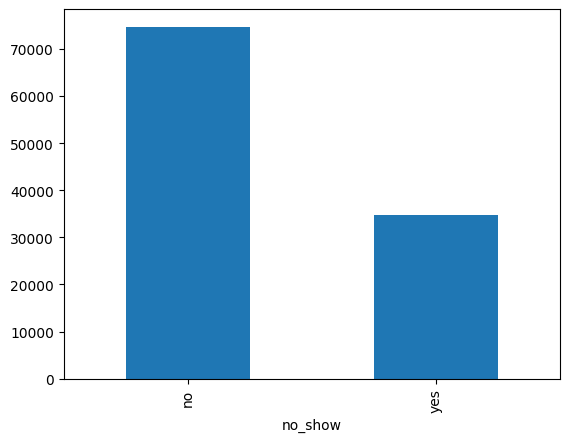

In [75]:
import matplotlib.pyplot as plt

df['no_show'].value_counts().plot(kind='bar')

plt.show()

In [76]:
cat_cols = df.select_dtypes(
    include=['object','category']
).columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].unique())


specialty
['psychotherapy', 'speech therapy', 'physiotherapy', 'occupational therapy', 'assist', 'pedagogo', 'enf', 'sem especialidade']
Categories (8, object): ['assist', 'enf', 'occupational therapy', 'pedagogo', 'physiotherapy', 'psychotherapy', 'sem especialidade', 'speech therapy']

gender
['F', 'M', 'I']
Categories (3, object): ['F', 'I', 'M']

no_show
['yes', 'no']
Categories (2, object): ['no', 'yes']

disability
['intellectual', 'motor', 0, ' ']
Categories (4, object): [0, ' ', 'intellectual', 'motor']

place
['Lake Marvinville', 'ITAPEMA', 'ITAJAÍ', 'Sarahside', 'Stokesfort', ..., 'Port Brenthaven', 'West Patrickborough', 'West Gregoryport', 'Reynoldsville', 'Wilcoxstad']
Length: 26289
Categories (26289, object): ['Aaronberg', 'Aaronborough', 'Aaronburgh', 'Aaronbury', ..., 'Zunigamouth', 'Zunigaport', 'Zunigatown', 'Zunigaview']

appointment_shift
['afternoon', 'morning']
Categories (2, object): ['afternoon', 'morning']

rain_intensity
['no_rain' 'moderate' 'weak' 'heavy']


In [77]:
#1. gender check (I value)
df['gender'].value_counts(dropna=False)

gender
M    82230
F    27074
I      247
Name: count, dtype: int64

In [78]:
df = df[df['gender'] != 'I']


In [79]:
df['gender'].value_counts()

gender
M    82230
F    27074
I        0
Name: count, dtype: int64

In [81]:
#2. disability Fix (Important)
df['disability'].value_counts(dropna=False)


disability
intellectual    62625
motor           29698
0               16562
                  419
Name: count, dtype: int64

In [82]:
df['disability'].value_counts(dropna=False)

disability
intellectual    62625
motor           29698
0               16562
                  419
Name: count, dtype: int64

In [83]:
#Remove category  → object  → replace 
df['disability'] = (
    df['disability']
    .astype(str)
)

df['disability'] = (
    df['disability']
    .replace({
        ' ': 'none',
        '0': 'none'
    })
)

In [85]:
df['disability'].unique()

array(['intellectual', 'motor', 'none'], dtype=object)

In [88]:


arr = np.array(['intellectual', 'motor', 'none'])

count_none = np.sum(arr == 'none')
print(count_none)

1


In [89]:


pd.Series(arr).value_counts()

intellectual    1
motor           1
none            1
Name: count, dtype: int64

In [ ]:
df['disability'].value_counts

In [91]:
(df['place'].astype(str).str.strip() == '').sum()

np.int64(0)

In [92]:
#4 pecialty Check
df['specialty'].value_counts(dropna=False)

specialty
psychotherapy           48506
speech therapy          22313
physiotherapy           20997
occupational therapy    11314
pedagogo                 3534
enf                      1681
assist                    635
sem especialidade         324
Name: count, dtype: int64

In [93]:
df.info()

df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 109304 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   specialty                    109304 non-null  category      
 1   appointment_time             109304 non-null  datetime64[ns]
 2   gender                       109304 non-null  category      
 3   no_show                      109304 non-null  category      
 4   disability                   109304 non-null  object        
 5   place                        109304 non-null  category      
 6   appointment_shift            109304 non-null  category      
 7   age                          109304 non-null  float64       
 8   under_12_years_old           109304 non-null  int64         
 9   over_60_years_old            109304 non-null  int64         
 10  patient_needs_companion      109304 non-null  int64         
 11  average_temp_day             10

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
count,109304,109304,109304,109304,109304,109304,109304,109304.000000,109304.000000,109304.000000,...,109304.000000,109304,109304,109304,109304.000000,109304.000000,109304.000000,109304.000000,109304.000000,109304.000000
unique,8,NaN,2,2,3,26229,2,NaN,NaN,NaN,...,NaN,4,5,498,NaN,NaN,NaN,NaN,NaN,NaN
top,psychotherapy,NaN,M,no,intellectual,ITAJAÍ,afternoon,NaN,NaN,NaN,...,NaN,no_rain,mild,02-04-2021,NaN,NaN,NaN,NaN,NaN,NaN
freq,48506,NaN,82230,74516,62625,31989,59154,NaN,NaN,NaN,...,NaN,76373,46858,1507,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1970-01-01 00:00:00.000000012,NaN,NaN,NaN,NaN,NaN,17.257164,0.446086,0.071516,...,0.937596,NaN,NaN,NaN,0.057948,0.023842,0.018471,0.009121,0.054948,0.311663
min,NaN,1970-01-01 00:00:00.000000007,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,0.000000,...,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1970-01-01 00:00:00.000000009,NaN,NaN,NaN,NaN,NaN,9.000000,0.000000,0.000000,...,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,1970-01-01 00:00:00.000000013,NaN,NaN,NaN,NaN,NaN,12.000000,0.000000,0.000000,...,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,1970-01-01 00:00:00.000000015,NaN,NaN,NaN,NaN,NaN,18.000000,1.000000,0.000000,...,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,NaN,1970-01-01 00:00:00.000000018,NaN,NaN,NaN,NaN,NaN,110.000000,1.000000,1.000000,...,1.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [94]:
df.shape

(109304, 26)

In [95]:
# 5.Numerical columns me weird values check
df['age'].describe()

count    109304.000000
mean         17.257164
std          15.953587
min           2.000000
25%           9.000000
50%          12.000000
75%          18.000000
max         110.000000
Name: age, dtype: float64

In [96]:
df[df['age'] > 100]['age'].value_counts()

age
106.0    44
110.0    20
108.0    20
Name: count, dtype: int64

In [99]:
(df['age'] > 100).sum()

np.int64(84)

In [104]:
weather_cols = [
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

df[weather_cols].describe()

,average_temp_day,average_rain_day,max_temp_day,max_rain_day
count,109304.000000,109304.000000,109304.000000,109304.000000
mean,20.358134,0.179260,24.042553,2.004117
std,3.410171,0.412541,3.911417,4.316668
min,8.940000,0.000000,13.300000,0.000000
25%,18.190000,0.000000,21.500000,0.000000
50%,20.600000,0.010000,23.900000,0.200000
75%,22.660000,0.140000,26.700000,1.800000
max,28.010000,4.770000,35.400000,45.000000


In [105]:
df.to_csv("../data/cleaned_data.csv", index=False)

In [106]:
df.shape

(109304, 26)